In [42]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor

# Nous chargeons le fichier AmesHousing deja nettoyé par notre app de data preprocessing qui automatise certaines taches comme le traitement des NaN, les outliers, la normalisation du texte et la suppression des colonnes avec 70% ou plus de NaN et la normalisation des colonnes numeriques selon la distribution des données

In [43]:
df = pd.read_csv(r"C:\Users\douah\Downloads\cleaned_AmesHousing2.csv")

In [44]:
df.head(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,0.000000,526301100,20,rl,1.000000,1.000000,pave,ir1,lvl,allpub,corner,gtl,names,norm,norm,1fam,1story,6,5,0.604743,0.166667,hip,compshg,brkface,plywood,stone,0.275269,ta,ta,cblock,ta,gd,gd,blq,0.348229,unf,0.0,0.263146,0.516101,gasa,fa,y,sbrkr,0.729732,0.000000,0,0.566440,1.0,0.0,1,0,3,1,ta,7,typ,2,gd,attchd,0.362179,fin,2.0,0.550000,ta,ta,p,0.500000,0.354286,0,0,0,0,0,5,2010,wd,normal,215000
1,0.000341,526350040,20,rh,0.652778,0.628327,pave,reg,lvl,allpub,inside,gtl,names,feedr,norm,1fam,1story,5,6,0.612648,0.183333,gable,compshg,vinylsd,vinylsd,brkface,0.000000,ta,ta,cblock,ta,ta,no,rec,0.255041,lwq,0.0,0.161110,0.418756,gasa,ta,y,sbrkr,0.310219,0.000000,0,0.240801,0.0,0.0,1,0,2,1,ta,5,typ,0,gd,attchd,0.368590,unf,1.0,0.760417,ta,ta,y,0.333333,0.000000,0,0,0,0,0,6,2010,wd,normal,105000
2,0.000683,526351010,20,rl,0.666667,0.789335,pave,ir1,lvl,allpub,corner,gtl,names,norm,norm,1fam,1story,6,6,0.588933,0.133333,hip,compshg,vinylsd,vinylsd,brkface,0.265438,ta,ta,cblock,ta,ta,no,alq,0.502997,unf,0.0,0.242262,0.638520,gasa,ta,y,sbrkr,0.549231,0.000000,0,0.426330,0.0,0.0,1,1,3,1,gd,6,typ,0,gd,attchd,0.349359,unf,1.0,0.325000,ta,ta,y,0.935714,0.205714,0,0,0,0,12500,6,2010,wd,normal,172000
3,0.001024,526353030,20,rl,0.833333,0.600204,pave,reg,lvl,allpub,corner,gtl,names,norm,norm,1fam,1story,7,5,0.667984,0.300000,hip,compshg,brkface,brkface,brkface,0.000000,gd,ta,cblock,ta,ta,no,alq,0.580381,unf,0.0,0.623555,1.000000,gasa,ex,y,sbrkr,0.980335,0.000000,0,0.760966,1.0,0.0,2,1,3,1,ex,8,typ,2,ta,attchd,0.413462,fin,2.0,0.543750,ta,ta,y,0.000000,0.000000,0,0,0,0,0,4,2010,wd,normal,244000
4,0.001366,527105010,60,rl,0.569444,0.762734,pave,ir1,lvl,allpub,inside,gtl,gilbert,norm,norm,1fam,2story,5,5,0.897233,0.800000,gable,compshg,vinylsd,vinylsd,brkface,0.000000,ta,ta,pconc,gd,ta,no,glq,0.431063,unf,0.0,0.081748,0.441372,gasa,gd,y,sbrkr,0.327882,0.398437,0,0.554871,0.0,0.0,2,1,3,1,ta,6,typ,1,ta,attchd,0.599359,fin,2.0,0.502083,ta,ta,y,0.504762,0.194286,0,0,0,0,0,3,2010,wd,normal,189900
5,0.001707,527105030,60,rl,0.625000,0.528252,pave,ir1,lvl,allpub,inside,gtl,gilbert,norm,norm,1fam,2story,6,6,0.905138,0.800000,gable,compshg,vinylsd,vinylsd,brkface,0.049155,ta,ta,pconc,ta,ta,no,glq,0.328065,unf,0.0,0.193332,0.440388,gasa,ex,y,sbrkr,0.326778,0.385364,0,0.544159,0.0,0.0,2,1,3,1,gd,7,typ,1,gd,attchd,0.605769,fin,2.0,0.489583,ta,ta,y,0.857143,0.205714,0,0,0,0,0,6,2010,wd,normal,195500
6,0.002048,527127150,120,rl,0.111111,0.220359,pave,reg,lvl,allpub,inside,gtl,stonebr,norm,norm,twnhse,1story,8,5,0.928854,0.850000,gable,compshg,cemntbd,cmentbd,brkface,0.000000,gd,ta,pconc,gd,ta,mn,glq,0.335695,unf,0.0,0.430820,0.642945,gasa,ex,y,sbrkr,0.554199,0.000000,0,0.430186,1.0,0.0,2,0,2,1,gd,6,typ,0,gd,attchd,0.625000,fin,2.0,0.606250,ta,ta,y,0.000000,0.000000,0,0,0,0,0,4,2010,wd,normal,213500
7,0.002390,527145080,120,rl,0.138889,0.225533,pave,ir1,hls,allpub,inside,gtl,stonebr,norm,norm,twnhse,1story,8,5,0.857708,0.700000,gable,compshg,hdboard,hdboard,brkface,0.000000,gd,ta,pconc,gd,ta,no,alq,0.143324,unf,0.0,0.606847,0.614430,gasa,ex,y,sbrkr,0.522183,0.

In [45]:
scaler = MinMaxScaler()
df["Yr Sold"] = scaler.fit_transform(df[["Yr Sold"]])

## Renommons les colonnes

In [46]:
rename_columns = {
"Order":"Numero_ordre",
"PID":"ID_parcelle",
"MS SubClass":"Sous_classe_batiment",
"MS Zoning":"Zone_urbaine",
"Lot Frontage":"Facade_terrain",
"Lot Area":"Surface_terrain",
"Street":"Type_rue",
"Lot Shape":"Forme_terrain",
"Land Contour":"Relief_terrain",
"Utilities":"Services_publics",
"Lot Config":"Configuration_terrain",
"Land Slope":"Pente_terrain",
"Neighborhood":"Quartier",
"Condition 1":"Condition_proximite_1",
"Condition 2":"Condition_proximite_2",
"Bldg Type":"Type_batiment",
"House Style":"Style_maison",
"Overall Qual":"Qualite_generale",
"Overall Cond":"Etat_general",
"Year Built":"Annee_construction",
"Year Remod/Add":"Annee_renovation",
"Roof Style":"Style_toit",
"Roof Matl":"Materiau_toit",
"Exterior 1st":"Exterieur_principal",
"Exterior 2nd":"Exterieur_secondaire",
"Mas Vnr Type":"Type_parement_maconnerie",
"Mas Vnr Area":"Surface_parement_maconnerie",
"Exter Qual":"Qualite_exterieure",
"Exter Cond":"Etat_exterieur",
"Foundation":"Fondation",
"Bsmt Qual":"Qualite_sous_sol",
"Bsmt Cond":"Etat_sous_sol",
"Bsmt Exposure":"Exposition_sous_sol",
"BsmtFin Type 1":"Type_finition_sous_sol_1",
"BsmtFin SF 1":"Surface_finie_sous_sol_1",
"BsmtFin Type 2":"Type_finition_sous_sol_2",
"BsmtFin SF 2":"Surface_finie_sous_sol_2",
"Bsmt Unf SF":"Surface_sous_sol_non_finie",
"Total Bsmt SF":"Surface_totale_sous_sol",
"Heating":"Chauffage",
"Heating QC":"Qualite_chauffage",
"Central Air":"Climatisation_centrale",
"Electrical":"Installation_electrique",
"1st Flr SF":"Surface_1er_etage",
"2nd Flr SF":"Surface_2eme_etage",
"Low Qual Fin SF":"Surface_finition_faible_qualite",
"Gr Liv Area":"Surface_habitable",
"Bsmt Full Bath":"Salle_bain_complete_sous_sol",
"Bsmt Half Bath":"Demi_salle_bain_sous_sol",
"Full Bath":"Salle_bain_complete",
"Half Bath":"Demi_salle_bain",
"Bedroom AbvGr":"Chambres_hors_sous_sol",
"Kitchen AbvGr":"Cuisines_hors_sous_sol",
"Kitchen Qual":"Qualite_cuisine",
"TotRms AbvGrd":"Nombre_total_pieces",
"Functional":"Fonctionnalite",
"Fireplaces":"Nombre_cheminees",
"Fireplace Qu":"Qualite_cheminee",
"Garage Type":"Type_garage",
"Garage Yr Blt":"Annee_construction_garage",
"Garage Finish":"Finition_garage",
"Garage Cars":"Capacite_garage_voitures",
"Garage Area":"Surface_garage",
"Garage Qual":"Qualite_garage",
"Garage Cond":"Etat_garage",
"Paved Drive":"Allee_pavee",
"Wood Deck SF":"Surface_terrasse_bois",
"Open Porch SF":"Surface_porche_ouvert",
"Enclosed Porch":"Porche_ferme",
"3Ssn Porch":"Porche_trois_saisons",
"Screen Porch":"Porche_moustiquaire",
"Pool Area":"Surface_piscine",
"Misc Val":"Valeur_element_divers",
"Mo Sold":"Mois_vente",
"Yr Sold":"Annee_vente",
"Sale Type":"Type_vente",
"Sale Condition":"Condition_vente",
"SalePrice":"Prix_vente"
}

In [47]:
df = df.rename(columns=rename_columns)

df_brut_pipeline = df.copy()
df_brut_pipeline["Total_salles_bain"] = (
    df_brut_pipeline["Salle_bain_complete"]
    + 0.5 * df_brut_pipeline["Demi_salle_bain"]
    + df_brut_pipeline["Salle_bain_complete_sous_sol"]
    + 0.5 * df_brut_pipeline["Demi_salle_bain_sous_sol"]
)

In [48]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 1000)

In [81]:
df.head(10)

,Numero_ordre,ID_parcelle,Sous_classe_batiment,Facade_terrain,Surface_terrain,Forme_terrain,Services_publics,Pente_terrain,Qualite_generale,Etat_general,Annee_construction,Annee_renovation,Surface_parement_maconnerie,Qualite_exterieure,Etat_exterieur,Qualite_sous_sol,Etat_sous_sol,Exposition_sous_sol,Type_finition_sous_sol_1,Surface_finie_sous_sol_1,Type_finition_sous_sol_2,Surface_finie_sous_sol_2,Surface_sous_sol_non_finie,Surface_totale_sous_sol,Qualite_chauffage,Surface_1er_etage,Surface_2eme_etage,Surface_finition_faible_qualite,Surface_habitable,Salle_bain_complete_sous_sol,Demi_salle_bain_sous_sol,Salle_bain_complete,Demi_salle_bain,Chambres_hors_sous_sol,Cuisines_hors_sous_sol,Qualite_cuisine,Nombre_total_pieces,Fonctionnalite,Nombre_cheminees,Qualite_cheminee,Annee_construction_garage,Finition_garage,Capacite_garage_voitures,Surface_garage,Qualite_garage,Etat_garage,Allee_pavee,Surface_terrasse_bois,Surface_porche_ouvert,Porche_ferme,Porche_trois_saisons,Porche_moustiquaire,Surface_piscine,Valeur_element_divers,Mois_vente,Annee_vente,Prix_vente,Zone_urbaine_rh,Zone_urbaine_rl,Zone_urbaine_rm,Type_rue_pave,Relief_terrain_hls,Relief_terrain_low,Relief_terrain_lvl,Configuration_terrain_culdsac,Configuration_terrain_inside,Quartier_blueste,Quartier_brdale,Quartier_brkside,Quartier_clearcr,Quartier_collgcr,Quartier_crawfor,Quartier_edwards,Quartier_gilbert,Quartier_greens,Quartier_grnhill,Quartier_idotrr,Quartier_landmrk,Quartier_meadowv,Quartier_mitchel,Quartier_names,Quartier_noridge,Quartier_npkvill,Quartier_nridght,Quartier_nwames,Quartier_oldtown,Quartier_sawyer,Quartier_sawyerw,Quartier_somerst,Quartier_stonebr,Quartier_swisu,Quartier_timber,Quartier_veenker,Condition_proximite_1_feedr,Condition_proximite_1_norm,Condition_proximite_1_posa,Condition_proximite_1_posn,Condition_proximite_1_rrae,Condition_proximite_1_rran,Condition_proximite_1_rrne,Condition_proximite_1_rrnn,Condition_proximite_2_feedr,Condition_proximite_2_norm,Condition_proximite_2_posa,Condition_proximite_2_posn,Condition_proximite_2_rrae,Condition_proximite_2_rran,Condition_proximite_2_rrnn,Type_batiment_2fmcon,Type_batiment_duplex,Type_batiment_twnhs,Type_batiment_twnhse,Style_maison_2story,Style_maison_sfoyer,Style_maison_slvl,Style_toit_gable,Style_toit_gambrel,Style_toit_hip,Style_toit_mansard,Style_toit_shed,Materiau_toit_compshg,Materiau_toit_membran,Materiau_toit_metal,Materiau_toit_roll,Materiau_toit_wdshake,Materiau_toit_wdshngl,Exterieur_principal_asphshn,Exterieur_principal_brkcomm,Exterieur_principal_brkface,Exterieur_principal_cblock,Exterieur_principal_cemntbd,Exterieur_principal_hdboard,Exterieur_principal_imstucc,Exterieur_principal_metalsd,Exterieur_principal_plywood,Exterieur_principal_precast,Exterieur_principal_stone,Exterieur_principal_stucco,Exterieur_principal_vinylsd,Exterieur_principal_wdshing,Exterieur_secondaire_asphshn,Exterieur_secondaire_brkface,Exterieur_secondaire_cblock,Exterieur_secondaire_cmentbd,Exterieur_secondaire_hdboard,Exterieur_secondaire_imstucc,Exterieur_secondaire_metalsd,Exterieur_secondaire_other,Exterieur_secondaire_plywood,Exterieur_secondaire_precast,Exterieur_secondaire_stone,Exterieur_secondaire_stucco,Exterieur_secondaire_vinylsd,Type_parement_maconnerie_brkface,Type_parement_maconnerie_cblock,Type_parement_maconnerie_stone,Fondation_cblock,Fondation_pconc,Fondation_slab,Fondation_stone,Fondation_wood,Chauffage_gasa,Chauffage_gasw,Chauffage_grav,Chauffage_othw,Chauffage_wall,Climatisation_centrale_y,Installation_electrique_fusef,Installation_electrique_fusep,Installation_electrique_mix,Installation_electrique_sbrkr,Type_garage_basment,Type_garage_builtin,Type_garage_carport,Type_garage_detchd,Type_vente_con,Type_vente_conld,Type_vente_conli,Type_vente_conlw,Type_vente_cwd,Type_vente_new,Type_vente_oth,Type_vente_vwd,Type_vente_wd,Condition_vente_adjland,Condition_vente_alloca,Condition_vente_family,Condition_vente_normal,Condition_vente_partial,Age_maison,Surface_totale,Total_salles_bain,Surface_to

# Encodons les colonnes catégorielles ordinales 

In [50]:
# dictionnaires d'encodage ordinal

qualite_5 = {"po":1,"fa":2,"ta":3,"gd":4,"ex":5}

bsmt_exposition = {"no":1,"mn":2,"av":3,"gd":4}

bsmt_finition = {"unf":1,"lwq":2,"rec":3,"blq":4,"alq":5,"glq":6}

fonctionnalite = {
"sal":1,
"sev":2,
"maj2":3,
"maj1":4,
"mod":5,
"min2":6,
"min1":7,
"typ":8
}

finitions_garage = {"unf":1,"rfn":2,"fin":3}

allee_pavee = {"n":0,"p":1,"y":2}

forme_terrain = {"ir3":1,"ir2":2,"ir1":3,"reg":4}

services_publics = {"elo":1,"nosewa":2,"nosewr":3,"allpub":4}

pente_terrain = {"sev":1,"mod":2,"gtl":3}


# application au dataframe

df["Forme_terrain"] = df["Forme_terrain"].map(forme_terrain)
df["Services_publics"] = df["Services_publics"].map(services_publics)
df["Pente_terrain"] = df["Pente_terrain"].map(pente_terrain)

df["Qualite_exterieure"] = df["Qualite_exterieure"].map(qualite_5)
df["Etat_exterieur"] = df["Etat_exterieur"].map(qualite_5)
df["Qualite_sous_sol"] = df["Qualite_sous_sol"].map(qualite_5)
df["Etat_sous_sol"] = df["Etat_sous_sol"].map(qualite_5)
df["Qualite_chauffage"] = df["Qualite_chauffage"].map(qualite_5)
df["Qualite_cuisine"] = df["Qualite_cuisine"].map(qualite_5)
df["Qualite_cheminee"] = df["Qualite_cheminee"].map(qualite_5)

df["Qualite_garage"] = df["Qualite_garage"].map(qualite_5)
df["Etat_garage"] = df["Etat_garage"].map(qualite_5)

df["Exposition_sous_sol"] = df["Exposition_sous_sol"].map(bsmt_exposition)
df["Type_finition_sous_sol_1"] = df["Type_finition_sous_sol_1"].map(bsmt_finition)
df["Type_finition_sous_sol_2"] = df["Type_finition_sous_sol_2"].map(bsmt_finition)

df["Fonctionnalite"] = df["Fonctionnalite"].map(fonctionnalite)
df["Finition_garage"] = df["Finition_garage"].map(finitions_garage)
df["Allee_pavee"] = df["Allee_pavee"].map(allee_pavee)

# Encodons les colonnes categorielles nominales

In [51]:
colonnes_nominales = [
    "Zone_urbaine", "Type_rue", "Relief_terrain", "Configuration_terrain",
    "Quartier", "Condition_proximite_1", "Condition_proximite_2",
    "Type_batiment", "Style_maison", "Style_toit", "Materiau_toit",
    "Exterieur_principal", "Exterieur_secondaire", "Type_parement_maconnerie",
    "Fondation", "Chauffage", "Climatisation_centrale",
    "Installation_electrique", "Type_garage", "Type_vente", "Condition_vente"
]

df = pd.get_dummies(df, columns=colonnes_nominales, drop_first=True)

In [52]:
df.head(20)

,Numero_ordre,ID_parcelle,Sous_classe_batiment,Facade_terrain,Surface_terrain,Forme_terrain,Services_publics,Pente_terrain,Qualite_generale,Etat_general,Annee_construction,Annee_renovation,Surface_parement_maconnerie,Qualite_exterieure,Etat_exterieur,Qualite_sous_sol,Etat_sous_sol,Exposition_sous_sol,Type_finition_sous_sol_1,Surface_finie_sous_sol_1,Type_finition_sous_sol_2,Surface_finie_sous_sol_2,Surface_sous_sol_non_finie,Surface_totale_sous_sol,Qualite_chauffage,Surface_1er_etage,Surface_2eme_etage,Surface_finition_faible_qualite,Surface_habitable,Salle_bain_complete_sous_sol,Demi_salle_bain_sous_sol,Salle_bain_complete,Demi_salle_bain,Chambres_hors_sous_sol,Cuisines_hors_sous_sol,Qualite_cuisine,Nombre_total_pieces,Fonctionnalite,Nombre_cheminees,Qualite_cheminee,Annee_construction_garage,Finition_garage,Capacite_garage_voitures,Surface_garage,Qualite_garage,Etat_garage,Allee_pavee,Surface_terrasse_bois,Surface_porche_ouvert,Porche_ferme,Porche_trois_saisons,Porche_moustiquaire,Surface_piscine,Valeur_element_divers,Mois_vente,Annee_vente,Prix_vente,Zone_urbaine_rh,Zone_urbaine_rl,Zone_urbaine_rm,Type_rue_pave,Relief_terrain_hls,Relief_terrain_low,Relief_terrain_lvl,Configuration_terrain_culdsac,Configuration_terrain_inside,Quartier_blueste,Quartier_brdale,Quartier_brkside,Quartier_clearcr,Quartier_collgcr,Quartier_crawfor,Quartier_edwards,Quartier_gilbert,Quartier_greens,Quartier_grnhill,Quartier_idotrr,Quartier_landmrk,Quartier_meadowv,Quartier_mitchel,Quartier_names,Quartier_noridge,Quartier_npkvill,Quartier_nridght,Quartier_nwames,Quartier_oldtown,Quartier_sawyer,Quartier_sawyerw,Quartier_somerst,Quartier_stonebr,Quartier_swisu,Quartier_timber,Quartier_veenker,Condition_proximite_1_feedr,Condition_proximite_1_norm,Condition_proximite_1_posa,Condition_proximite_1_posn,Condition_proximite_1_rrae,Condition_proximite_1_rran,Condition_proximite_1_rrne,Condition_proximite_1_rrnn,Condition_proximite_2_feedr,Condition_proximite_2_norm,Condition_proximite_2_posa,Condition_proximite_2_posn,Condition_proximite_2_rrae,Condition_proximite_2_rran,Condition_proximite_2_rrnn,Type_batiment_2fmcon,Type_batiment_duplex,Type_batiment_twnhs,Type_batiment_twnhse,Style_maison_2story,Style_maison_sfoyer,Style_maison_slvl,Style_toit_gable,Style_toit_gambrel,Style_toit_hip,Style_toit_mansard,Style_toit_shed,Materiau_toit_compshg,Materiau_toit_membran,Materiau_toit_metal,Materiau_toit_roll,Materiau_toit_wdshake,Materiau_toit_wdshngl,Exterieur_principal_asphshn,Exterieur_principal_brkcomm,Exterieur_principal_brkface,Exterieur_principal_cblock,Exterieur_principal_cemntbd,Exterieur_principal_hdboard,Exterieur_principal_imstucc,Exterieur_principal_metalsd,Exterieur_principal_plywood,Exterieur_principal_precast,Exterieur_principal_stone,Exterieur_principal_stucco,Exterieur_principal_vinylsd,Exterieur_principal_wdshing,Exterieur_secondaire_asphshn,Exterieur_secondaire_brkface,Exterieur_secondaire_cblock,Exterieur_secondaire_cmentbd,Exterieur_secondaire_hdboard,Exterieur_secondaire_imstucc,Exterieur_secondaire_metalsd,Exterieur_secondaire_other,Exterieur_secondaire_plywood,Exterieur_secondaire_precast,Exterieur_secondaire_stone,Exterieur_secondaire_stucco,Exterieur_secondaire_vinylsd,Type_parement_maconnerie_brkface,Type_parement_maconnerie_cblock,Type_parement_maconnerie_stone,Fondation_cblock,Fondation_pconc,Fondation_slab,Fondation_stone,Fondation_wood,Chauffage_gasa,Chauffage_gasw,Chauffage_grav,Chauffage_othw,Chauffage_wall,Climatisation_centrale_y,Installation_electrique_fusef,Installation_electrique_fusep,Installation_electrique_mix,Installation_electrique_sbrkr,Type_garage_basment,Type_garage_builtin,Type_garage_carport,Type_garage_detchd,Type_vente_con,Type_vente_conld,Type_vente_conli,Type_vente_conlw,Type_vente_cwd,Type_vente_new,Type_vente_oth,Type_vente_vwd,Type_vente_wd,Condition_vente_adjland,Condition_vente_alloca,Condition_vente_family,Condition_vente_normal,Condition_vente_partial
0,0.000000,526301100,20,1.000000,1.000000,3,4,3,6,5,0.

## Features engeneering: creation des nouvelles variables pour ameliorer la prediction

In [53]:
df["Age_maison"] = df["Annee_vente"] - df["Annee_construction"]

In [54]:
df["Surface_totale"] = (
    df["Surface_1er_etage"] +
    df["Surface_2eme_etage"] +
    df["Surface_totale_sous_sol"]
)

In [55]:
df["Total_salles_bain"] = (
    df["Salle_bain_complete"] +
    0.5 * df["Demi_salle_bain"] +
    df["Salle_bain_complete_sous_sol"] +
    0.5 * df["Demi_salle_bain_sous_sol"]
)

In [56]:
df["Surface_totale_porche"] = (
    df["Surface_porche_ouvert"] +
    df["Porche_ferme"] +
    df["Porche_trois_saisons"] +
    df["Porche_moustiquaire"]
)

In [57]:
df["Surface_totale_exterieure"] = (
    df["Surface_terrasse_bois"] +
    df["Surface_totale_porche"]
)

In [58]:
df[[
"Age_maison",
"Surface_totale",
"Total_salles_bain",
"Surface_totale_porche",
"Surface_totale_exterieure",
]].head()

,Age_maison,Surface_totale,Total_salles_bain,Surface_totale_porche,Surface_totale_exterieure
0,0.395257,1.245833,2.0,0.354286,0.854286
1,0.387352,0.728975,1.0,0.000000,0.333333
2,0.411067,1.187751,1.5,0.205714,1.141429
3,0.332016,1.980335,3.5,0.000000,0.000000
4,0.102767,1.167691,2.5,0.194286,0.699048


## verifions la correlation

In [59]:
corr = df.corr()

corr["Prix_vente"].sort_values(ascending=False)

Prix_vente                          1.000000
Surface_totale                      0.821972
Qualite_generale                    0.821794
Surface_habitable                   0.726883
Qualite_exterieure                  0.709006
Qualite_sous_sol                    0.697785
Qualite_cuisine                     0.686232
Capacite_garage_voitures            0.676674
Surface_garage                      0.668274
Total_salles_bain                   0.661278
Surface_totale_sous_sol             0.648421
Surface_1er_etage                   0.633557
Annee_construction                  0.603326
Salle_bain_complete                 0.576046
Annee_renovation                    0.575350
Finition_garage                     0.572918
Fondation_pconc                     0.557165
Annee_construction_garage           0.547851
Nombre_total_pieces                 0.492569
Nombre_cheminees                    0.492291
Qualite_chauffage                   0.483479
Surface_parement_maconnerie         0.479260
Surface_fi

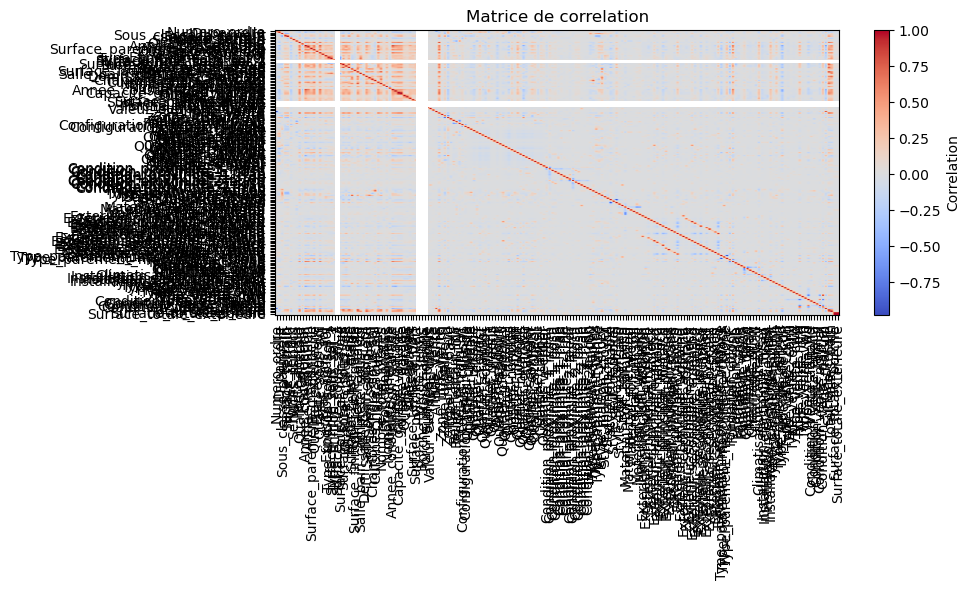

In [79]:
plt.figure(figsize=(10, 6))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matrice de correlation")
plt.tight_layout()
plt.show()

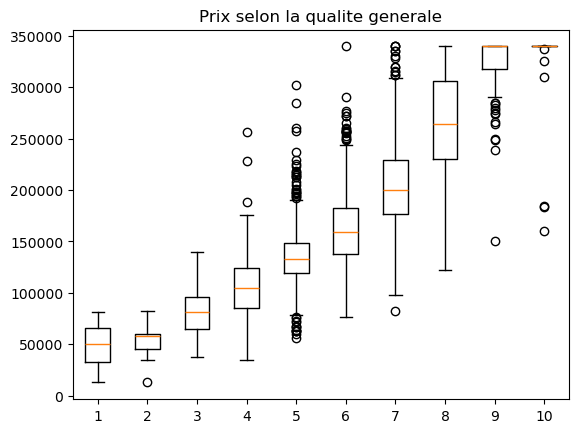

In [61]:
plt.boxplot([df[df["Qualite_generale"]==i]["Prix_vente"] for i in sorted(df["Qualite_generale"].unique())])
plt.title("Prix selon la qualite generale")
plt.show()

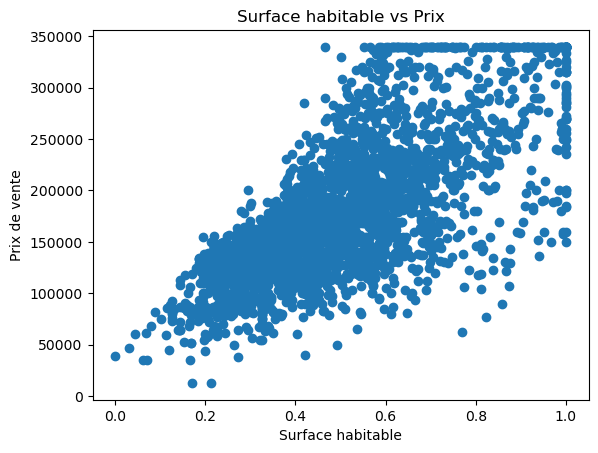

In [62]:
plt.scatter(df["Surface_habitable"], df["Prix_vente"])
plt.xlabel("Surface habitable")
plt.ylabel("Prix de vente")
plt.title("Surface habitable vs Prix")
plt.show()

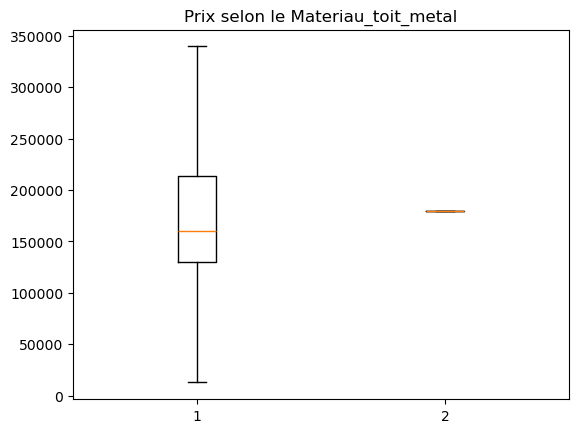

In [63]:
plt.boxplot([df[df["Materiau_toit_metal"]==i]["Prix_vente"] for i in sorted(df["Materiau_toit_metal"].unique())])
plt.title("Prix selon le Materiau_toit_metal")
plt.show()

## Entrainement du modèle

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


def preprocess_ames(df):
    df = df.copy()

    # feature engineering du haut
    df["Age_maison"] = df["Annee_vente"] - df["Annee_construction"]
    df["Surface_totale"] = (
        df["Surface_1er_etage"]
        + df["Surface_2eme_etage"]
        + df["Surface_totale_sous_sol"]
    )
    if "Total_salles_bain" not in df.columns:
        df["Total_salles_bain"] = (
            df["Salle_bain_complete"]
            + 0.5 * df["Demi_salle_bain"]
            + df["Salle_bain_complete_sous_sol"]
            + 0.5 * df["Demi_salle_bain_sous_sol"]
        )
    df["Surface_totale_porche"] = (
        df["Surface_porche_ouvert"]
        + df["Porche_ferme"]
        + df["Porche_trois_saisons"]
        + df["Porche_moustiquaire"]
    )
    df["Surface_totale_exterieure"] = (
        df["Surface_terrasse_bois"] + df["Surface_totale_porche"]
    )

    # encodages ordinaux du haut, robustes pour train et new_data
    encodages_ordinaux = {
        "Forme_terrain": forme_terrain,
        "Services_publics": services_publics,
        "Pente_terrain": pente_terrain,
        "Qualite_exterieure": qualite_5,
        "Etat_exterieur": qualite_5,
        "Qualite_sous_sol": qualite_5,
        "Etat_sous_sol": qualite_5,
        "Qualite_chauffage": qualite_5,
        "Qualite_cuisine": qualite_5,
        "Qualite_cheminee": qualite_5,
        "Qualite_garage": qualite_5,
        "Etat_garage": qualite_5,
        "Exposition_sous_sol": bsmt_exposition,
        "Type_finition_sous_sol_1": bsmt_finition,
        "Type_finition_sous_sol_2": bsmt_finition,
        "Fonctionnalite": fonctionnalite,
        "Finition_garage": finitions_garage,
        "Allee_pavee": allee_pavee
    }

    for colonne, mapping in encodages_ordinaux.items():
        if colonne in df.columns and pd.api.types.is_object_dtype(df[colonne]):
            df[colonne] = df[colonne].map(mapping)

    # colonnes binaires utiles au modèle final, robustes sur une seule ligne
    if "Climatisation_centrale" in df.columns:
        df["Climatisation_centrale_y"] = (
            df["Climatisation_centrale"].astype(str).str.lower() == "y"
        ).astype(int)
    if "Zone_urbaine" in df.columns:
        df["Zone_urbaine_rm"] = (
            df["Zone_urbaine"].astype(str).str.lower() == "rm"
        ).astype(int)

    # encodage nominal du haut
    colonnes_nominales_pipeline = [
        "Type_rue", "Relief_terrain", "Configuration_terrain",
        "Quartier", "Condition_proximite_1", "Condition_proximite_2",
        "Type_batiment", "Style_maison", "Style_toit", "Materiau_toit",
        "Exterieur_principal", "Exterieur_secondaire", "Type_parement_maconnerie",
        "Fondation", "Chauffage",
        "Installation_electrique", "Type_garage", "Type_vente", "Condition_vente"
    ]

    colonnes_nominales_existantes = [
        colonne for colonne in colonnes_nominales_pipeline if colonne in df.columns
    ]
    if colonnes_nominales_existantes:
        df = pd.get_dummies(df, columns=colonnes_nominales_existantes, drop_first=True)

    # garder uniquement les colonnes finales utilisées par ton modèle
    colonnes_finales = [
        "Qualite_generale",
        "Surface_habitable",
        "Surface_totale",
        "Annee_construction",
        "Surface_totale_sous_sol",
        "Surface_finie_sous_sol_1",
        "Qualite_sous_sol",
        "Surface_garage",
        "Surface_terrain",
        "Surface_1er_etage",
        "Annee_renovation",
        "Qualite_cuisine",
        "Total_salles_bain",
        "Capacite_garage_voitures",
        "Climatisation_centrale_y",
        "Surface_sous_sol_non_finie",
        "Etat_general",
        "Annee_construction_garage",
        "Surface_totale_exterieure",
        "Age_maison",
        "Zone_urbaine_rm",
        "Facade_terrain"
    ]

    return df.reindex(columns=colonnes_finales, fill_value=0)

In [65]:
X = df.drop(["Prix_vente","ID_parcelle","Numero_ordre"], axis=1)
y = df["Prix_vente"]

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

### Feature importance

In [67]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [68]:
importance = pd.Series(
    rf.feature_importances_, index= X.columns).sort_values(ascending =False)

In [69]:
importance.head(30)

Qualite_generale                0.480853
Surface_totale                  0.317793
Total_salles_bain               0.016045
Annee_construction              0.015993
Surface_habitable               0.010364
Surface_garage                  0.009922
Surface_terrain                 0.009786
Annee_renovation                0.009033
Qualite_cuisine                 0.008516
Surface_finie_sous_sol_1        0.008263
Capacite_garage_voitures        0.007516
Surface_sous_sol_non_finie      0.006931
Qualite_sous_sol                0.005038
Nombre_cheminees                0.004702
Surface_1er_etage               0.004262
Etat_general                    0.004249
Annee_construction_garage       0.004108
Surface_totale_exterieure       0.003801
Age_maison                      0.003721
Surface_totale_sous_sol         0.003386
Surface_2eme_etage              0.003275
Facade_terrain                  0.003168
Climatisation_centrale_y        0.002905
Qualite_exterieure              0.002493
Mois_vente      

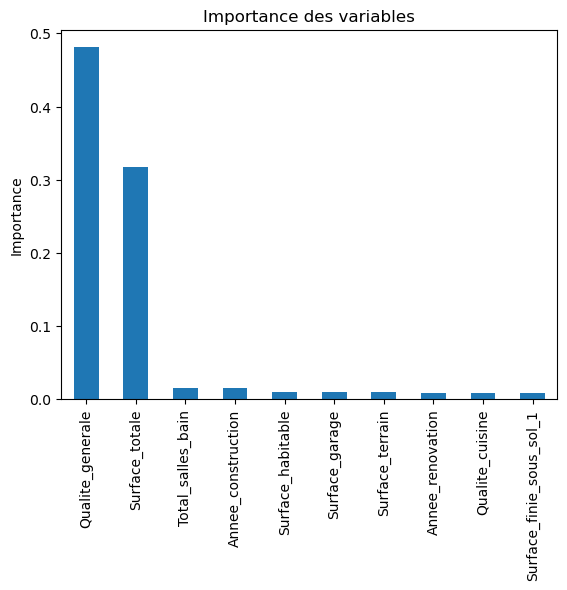

In [70]:
importance.head(10).plot(kind="bar")

plt.title("Importance des variables")
plt.ylabel("Importance")
plt.show()

In [71]:
important_features = importance[importance > 0.003].index

X = X[important_features]

### Model

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [73]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.92900849087716

In [74]:
y_pred = model.predict(X_test)
residuals = y_test - y_pred
q_low, q_high = np.percentile(residuals, [2.5, 97.5])
lower_bounds = y_pred + q_low
upper_bounds = y_pred + q_high

In [75]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

MAE: 13405.25794197952
Mean Squared Error: 378321671.7496766
R-squared: 0.92900849087716


In [76]:
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")

RMSE: 19450.492840791376


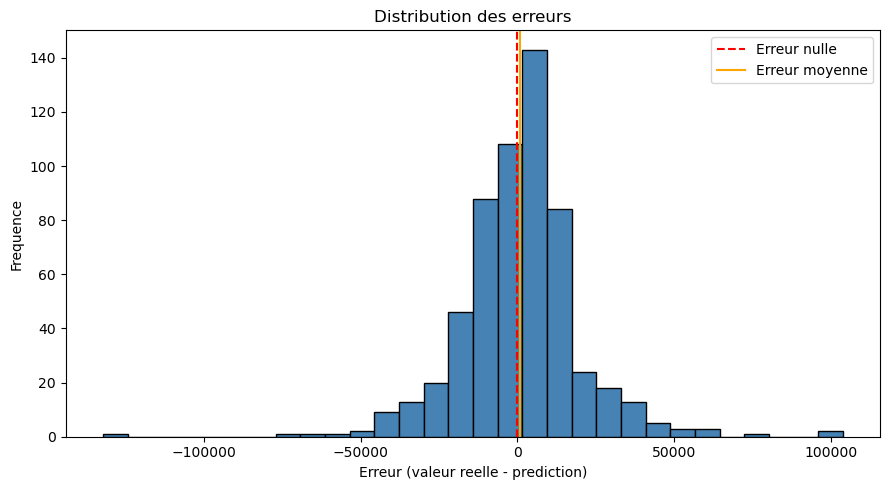

In [78]:
plt.figure(figsize=(9, 5))
plt.hist(residuals, bins=30, color="steelblue", edgecolor="black")
plt.axvline(0, color="red", linestyle="--", label="Erreur nulle")
plt.axvline(residuals.mean(), color="orange", linestyle="-", label="Erreur moyenne")
plt.title("Distribution des erreurs")
plt.xlabel("Erreur (valeur reelle - prediction)")
plt.ylabel("Frequence")
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
prediction_intervals = pd.DataFrame({
    "prediction": y_pred,
    "ic_95_basse": lower_bounds,
    "ic_95_haute": upper_bounds,
    "residu": residuals.values,
    "valeur_reelle": y_test.values,
})
prediction_intervals.head()

,prediction,ic_95_basse,ic_95_haute,residu,valeur_reelle
0,170660.99,134897.92625,214400.59625,-9660.99,161000
1,102273.50,66510.43625,146013.10625,13726.50,116000
2,195993.28,160230.21625,239732.88625,506.72,196500
3,112074.58,76311.51625,155814.18625,11525.42,123600
4,117291.00,81527.93625,161030.60625,8709.00,126000


In [73]:
pipeline = Pipeline([
    ("preprocessing", FunctionTransformer(preprocess_ames, validate=False)),
    ("scaler", MinMaxScaler()),
    ("model", RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=42
    ))
])

colonnes_brutes = [
    "Qualite_generale",
    "Surface_habitable",
    "Surface_1er_etage",
    "Surface_2eme_etage",
    "Surface_totale_sous_sol",
    "Surface_finie_sous_sol_1",
    "Qualite_sous_sol",
    "Surface_garage",
    "Surface_terrain",
    "Annee_renovation",
    "Qualite_cuisine",
    "Total_salles_bain",
    "Capacite_garage_voitures",
    "Climatisation_centrale",
    "Surface_sous_sol_non_finie",
    "Etat_general",
    "Annee_construction_garage",
    "Facade_terrain",
    "Annee_vente",
    "Annee_construction",
    "Zone_urbaine",
    "Surface_terrasse_bois",
    "Surface_porche_ouvert",
    "Porche_ferme",
    "Porche_trois_saisons",
    "Porche_moustiquaire"
]

X_brut = df_brut_pipeline[colonnes_brutes]
y = df_brut_pipeline["Prix_vente"]

X_train, X_test, y_train, y_test = train_test_split(
    X_brut, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

pipeline_y_pred = pipeline.predict(X_test)
pipeline_residuals = y_test - pipeline_y_pred
pipeline_q_low, pipeline_q_high = np.percentile(pipeline_residuals, [2.5, 97.5])

model_bundle = {
    "pipeline": pipeline,
    "residual_quantiles": {
        "q_low": float(pipeline_q_low),
        "q_high": float(pipeline_q_high),
        "level": 0.95,
    },
}

joblib.dump(model_bundle, "model_pipeline_complet6.pkl")

['model_pipeline_complet6.pkl']